In [18]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE = "raw_csv/type2_breakdown_Ag"
files = [f for f in os.listdir(BASE) if f.lower().endswith(".csv") and not f.startswith("~")]

print("Found files:", len(files))
print(files)

Found files: 5
['MeO2PACz_Ag_scan_10V.csv', 'NiOx_Ag_scan_10V.csv', 'PEDOT_Ag_scan_10V.csv', 'polyTPD_Ag_scan_10V.csv', 'PTAA_Ag_scan_10V.csv']


In [19]:
all_curves = []

for f in files:
    htl = f.split("_")[0]
    path = os.path.join(BASE, f)

    try:
        df = pd.read_csv(path, encoding="utf-8")
    except UnicodeDecodeError:
        df = pd.read_csv(path, encoding="latin1")

    df.columns = [c.lower().strip() for c in df.columns]

    if "voltage" not in df.columns or "current" not in df.columns:
        print("Skipping:", f)
        continue

    df["voltage"] = pd.to_numeric(df["voltage"], errors="coerce")
    df["current"] = pd.to_numeric(df["current"], errors="coerce")
    df = df.dropna(subset=["voltage", "current"])

    df["HTL"] = htl
    all_curves.append(df)

curves = pd.concat(all_curves, ignore_index=True)
curves.head()

,voltage,current,HTL
0,1.50,-414.630968,MeO2PACz
1,1.48,-385.656368,MeO2PACz
2,1.46,-356.903254,MeO2PACz
3,1.44,-328.702929,MeO2PACz
4,1.42,-301.120664,MeO2PACz


In [20]:
curves["HTL"].value_counts()

HTL
NiOx        601
PTAA        601
polyTPD     601
PEDOT       351
MeO2PACz    151
Name: count, dtype: int64

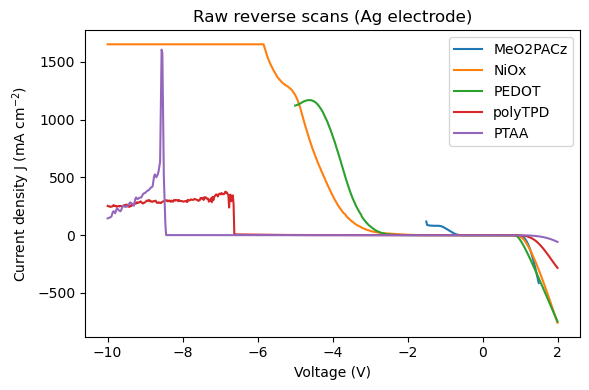

In [21]:
plt.figure(figsize=(6,4))

for htl in curves["HTL"].unique():
    g = curves[curves["HTL"] == htl].sort_values("voltage")
    plt.plot(g["voltage"], g["current"], label=htl)

plt.xlabel("Voltage (V)")
plt.ylabel(r"Current density J (mA cm$^{-2}$)")
plt.title("Raw reverse scans (Ag electrode)")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
def extract_vbr_hybrid(df, Jmin=1.0, slope_factor=5):
    df = df.sort_values("voltage")
    V = df["voltage"].to_numpy()
    J = np.abs(df["current"].to_numpy())

    # numerical derivative
    dJdV = np.gradient(J, V)

    # baseline slope from weak reverse region
    mask = (V <= -0.3) & (V >= -1.5)
    base = np.nanmedian(np.abs(dJdV[mask]))
    if not np.isfinite(base) or base == 0:
        base = np.nanmedian(np.abs(dJdV))

    slope_thr = slope_factor * base

    # candidates where both conditions are satisfied
    candidates = np.where((J >= Jmin) & (np.abs(dJdV) >= slope_thr))[0]

    if len(candidates) == 0:
        return np.nan

    return V[candidates[0]]

In [23]:
rows = []

for htl in curves["HTL"].unique():
    g = curves[curves["HTL"] == htl]
    vbr = extract_vbr_hybrid(g, Jmin=1.0, slope_factor=5)
    rows.append({"HTL": htl, "Vbr": vbr})

vbr_df = pd.DataFrame(rows)
vbr_df


,HTL,Vbr
0,MeO2PACz,-1.50
1,NiOx,-6.56
2,PEDOT,-5.00
3,polyTPD,-10.00
4,PTAA,-10.00


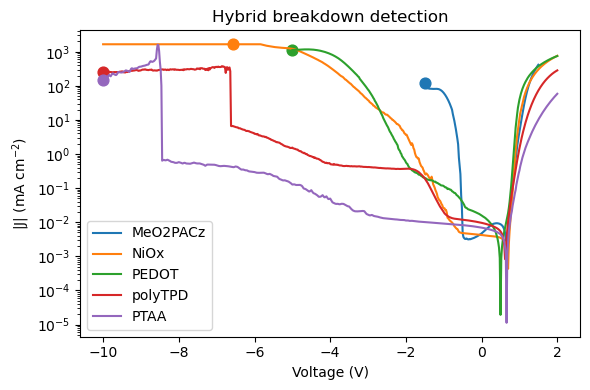

In [24]:
plt.figure(figsize=(6,4))

for htl in curves["HTL"].unique():
    g = curves[curves["HTL"] == htl].sort_values("voltage")
    V = g["voltage"]
    J = np.abs(g["current"])

    plt.plot(V, J, label=htl)

    vbr = vbr_df.loc[vbr_df["HTL"] == htl, "Vbr"].values[0]
    if np.isfinite(vbr):
        idx = (V - vbr).abs().idxmin()
        plt.scatter(V.loc[idx], J.loc[idx], s=60)

plt.yscale("log")
plt.xlabel("Voltage (V)")
plt.ylabel(r"|J| (mA cm$^{-2}$)")
plt.title("Hybrid breakdown detection")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
scan_min = curves["voltage"].min()

vbr_df["censored"] = vbr_df["Vbr"] <= scan_min
vbr_df["|Vbr|"] = vbr_df["Vbr"].abs()

vbr_df

,HTL,Vbr,censored,|Vbr|
0,MeO2PACz,-1.50,False,1.50
1,NiOx,-6.56,False,6.56
2,PEDOT,-5.00,False,5.00
3,polyTPD,-10.00,True,10.00
4,PTAA,-10.00,True,10.00


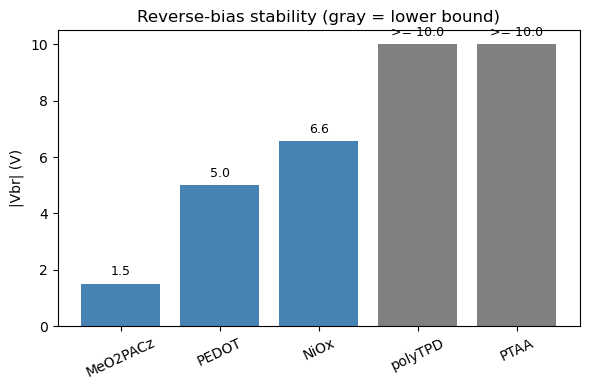

In [26]:
tmp = vbr_df.sort_values("|Vbr|")

colors = ["gray" if c else "steelblue" for c in tmp["censored"]]

plt.figure(figsize=(6,4))
plt.bar(tmp["HTL"], tmp["|Vbr|"], color=colors)
plt.ylabel("|Vbr| (V)")
plt.title("Reverse-bias stability (gray = lower bound)")
plt.xticks(rotation=25)

for i, row in tmp.reset_index(drop=True).iterrows():
    label = f">= {row['|Vbr|']:.1f}" if row["censored"] else f"{row['|Vbr|']:.1f}"
    plt.text(i, row["|Vbr|"] + 0.3, label, ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [27]:
vbr_df.to_csv("HTL_vs_Vbr_Ag_annotated.csv", index=False)
print("Saved: HTL_vs_Vbr_Ag_annotated.csv")

Saved: HTL_vs_Vbr_Ag_annotated.csv


In [28]:
curves.to_csv("type2_breakdown_Ag_all_curves.csv", index=False)
print("Saved: type2_breakdown_Ag_all_curves.csv")

Saved: type2_breakdown_Ag_all_curves.csv


In [29]:
summary = curves.groupby("HTL")["current"].agg(["mean", "std", "max"])
summary

,mean,std,max
HTL,,,
MeO2PACz,-8.063769,88.313362,118.211350
NiOx,717.879333,797.579880,1653.293071
PEDOT,161.701840,455.032868,1169.587955
PTAA,46.197909,155.231831,1606.036446
polyTPD,75.277776,144.012039,376.696222


In [30]:
vbr_stats = vbr_df.groupby("HTL")["Vbr"].agg(["mean", "std", "min", "max"])
vbr_stats

,mean,std,min,max
HTL,,,,
MeO2PACz,-1.50,NaN,-1.50,-1.50
NiOx,-6.56,NaN,-6.56,-6.56
PEDOT,-5.00,NaN,-5.00,-5.00
PTAA,-10.00,NaN,-10.00,-10.00
polyTPD,-10.00,NaN,-10.00,-10.00


In [31]:
features = vbr_df.copy()
features["Electrode"] = "Ag"
features["Scan_min_V"] = curves["voltage"].min()
features["Scan_max_V"] = curves["voltage"].max()
features

,HTL,Vbr,censored,|Vbr|,Electrode,Scan_min_V,Scan_max_V
0,MeO2PACz,-1.50,False,1.50,Ag,-10.0,2.0
1,NiOx,-6.56,False,6.56,Ag,-10.0,2.0
2,PEDOT,-5.00,False,5.00,Ag,-10.0,2.0
3,polyTPD,-10.00,True,10.00,Ag,-10.0,2.0
4,PTAA,-10.00,True,10.00,Ag,-10.0,2.0


In [32]:
features.to_csv("perovAI_features_type2_Ag.csv", index=False)
print("Saved: perovAI_features_type2_Ag.csv")

Saved: perovAI_features_type2_Ag.csv


In [34]:
test = pd.DataFrame({
    "HTL": ["NiOx","NiOx","NiOx"],
    "Vbr": [-6.2, -6.5, -6.9]
})

test.groupby("HTL")["Vbr"].agg(["mean","std","min","max"])

,mean,std,min,max
HTL,,,,
NiOx,-6.533333,0.351188,-6.9,-6.2
